In [1]:

import torch
import numpy as np


In [2]:

# =========================
# SIMPLE DIFFUSION DEMO
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [3]:

# =========================
# DATA (MNIST)
# =========================
transform = T.Compose([
    T.ToTensor()
])

train_ds = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

train_dl = torch.utils.data.DataLoader(
    train_ds, batch_size=64, shuffle=True
)



In [4]:


# =========================
# SIMPLE U-NET
# =========================
class SimpleUNet(nn.Module):

    def __init__(self):
        super().__init__()

        # down
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        # bottleneck
        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        # up
        self.up = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU()
        )

        # output (predict noise)
        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)

        m = self.mid(e2)

        u = self.up(m)
        cat = torch.cat([u, e1], dim=1)

        d = self.dec1(cat)

        return self.out(d)


In [5]:


# =========================
# MODEL
# =========================
model = SimpleUNet().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [6]:

# =========================
# TRAINING
# =========================
EPOCHS = 3

for epoch in range(EPOCHS):
    for xb, _ in train_dl:

        xb = xb.to(device)

        noise = torch.randn_like(xb)

        t = torch.rand(1).item()   # noise level (simple version)
        x_noisy = xb + t * noise

        pred = model(x_noisy)



        loss = loss_fn(pred, noise)

        opt.zero_grad()
        loss.backward()
        opt.step()

    print(f"Epoch {epoch} loss: {loss.item():.4f}")


Epoch 0 loss: 0.1638
Epoch 1 loss: 0.1231
Epoch 2 loss: 0.0540


In [7]:

# =========================
# SAMPLING
# =========================
model.eval()

x = torch.randn(1,1,28,28).to(device)

steps = 20
images = []

with torch.no_grad():
    for i in range(steps):
        noise_pred = model(x)
        x = x - 0.1 * noise_pred
        images.append(x.detach().cpu())


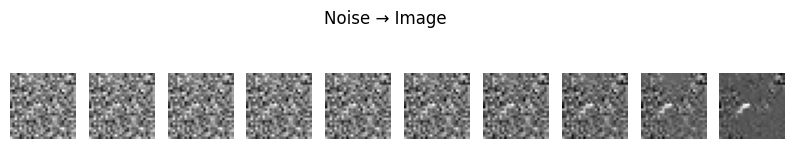

In [8]:

# =========================
# PLOT RESULT
# =========================
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(images[i][0,0], cmap='gray')
    plt.axis('off')

plt.suptitle("Noise → Image")
plt.show()



In [1]:

import nbformat

# load notebook
nb = nbformat.read("SuperSimpleS.ipynb", as_version=4)

# remove problematic widget metadata
if "widgets" in nb["metadata"]:
    nb["metadata"].pop("widgets")

# also clean each cell just in case
for cell in nb["cells"]:
    if "metadata" in cell and "widgets" in cell["metadata"]:
        cell["metadata"].pop("widgets")

# save cleaned notebook (overwrite or new file)
nbformat.write(nb, "cleaned_notebook.ipynb")


FileNotFoundError: [Errno 2] No such file or directory: 'your_notebook.ipynb'